# Xử lý & Trực quan hóa dữ liệu Spotify

**Input:** `data/raw/spotify_hybrid_tracks.csv`

**Output (text/EDA):**
- `data/processed/spotify_hybrid_processed.csv`
- `data/processed/processing_summary.json`
- `data/processed/figures/` — biểu đồ 01–04 (mood, nguồn, nhãn)

**Output (audio):**
- `data/processed/deezer_audio_checkpoint.csv` — crawl Deezer (resume được)
- `data/processed/spotify_audio_training.csv` — snapshot train (`audio_status=ok`, schema v2)
- `data/processed/audio_training_summary.json`
- `data/processed/figures/05_audio_crawl_snapshot.png`

**Crawl:** `python scripts/fetch_deezer_audio.py --per-mood 500 --delay 0.4`  
**Snapshot trong notebook:** Bước 7b (chạy lại sau khi crawl thêm).

## Bước 0 — Cài thư viện & import

In [1]:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import json
import re
import string
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

sns.set_theme(style="whitegrid")
FIGURE_DPI = 120

## Bước 1 — Cấu hình đường dẫn

In [2]:
ROOT = Path(".").resolve()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"
SCRIPTS_DIR = ROOT / "scripts"

INPUT_FILE = RAW_DIR / "spotify_hybrid_tracks.csv"
OUTPUT_FILE = PROCESSED_DIR / "spotify_hybrid_processed.csv"
SUMMARY_FILE = PROCESSED_DIR / "processing_summary.json"
AUDIO_CHECKPOINT = PROCESSED_DIR / "deezer_audio_checkpoint.csv"
AUDIO_TRAINING_FILE = PROCESSED_DIR / "spotify_audio_training.csv"
AUDIO_SUMMARY_FILE = PROCESSED_DIR / "audio_training_summary.json"
WESTERN_SAMPLE_FILE = PROCESSED_DIR / "spotify_western_sample.csv"

for _path in (ROOT, SCRIPTS_DIR):
    _path_str = str(_path)
    if _path_str not in sys.path:
        sys.path.insert(0, _path_str)

from deezer_io import build_western_sample  # pyright: ignore[reportMissingImports]
from fetch_deezer_audio import (  # pyright: ignore[reportMissingImports]
    CHECKPOINT_META_COLS,
    FEATURE_COLS,
    FEATURE_SCHEMA,
    needs_reextract,
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input:  {INPUT_FILE}")
print(f"Output: {OUTPUT_FILE}")
print(f"Scripts: {SCRIPTS_DIR}")

Input:  C:\Users\User\Desktop\idk\ds\data\raw\spotify_hybrid_tracks.csv
Output: C:\Users\User\Desktop\idk\ds\data\processed\spotify_hybrid_processed.csv
Scripts: C:\Users\User\Desktop\idk\ds\scripts


## Bước 2 — Đọc dữ liệu raw

In [3]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Không tìm thấy {INPUT_FILE}")

df = pd.read_csv(INPUT_FILE)
initial_rows = len(df)
print(f"Loaded {initial_rows} tracks, {len(df.columns)} columns")
df.head()

Loaded 10197 tracks, 27 columns


,track_id,track_name,artists,artist_ids,album,release_date,popularity,duration_ms,preview_url,spotify_url,...,source_type,source_id,source_name,track_name_clean,artists_clean,data_origin,mood_label,search_query,tags,genres
0,67NAtoGMdqY6nGZ6NIEdp0,Santa Monica,BUBBLE TEA AND CIGARETTES,2UMeX51X1prCFgi51RHo9P,There's Nothing But Pleasure,2022-09-02,NaN,344697,NaN,https://open.spotify.com/track/67NAtoGMdqY6nGZ...,...,liked,liked,Liked Songs,santa monica,bubble tea and cigarettes,profile,NaN,NaN,NaN,NaN
1,6ta5yavnnEfCE4faU0jebM,Mr Blue,Catherine Feeny,2PKUc5LXsZNjqOpAZKcFgz,Hurricane Glass,2006,NaN,154600,NaN,https://open.spotify.com/track/6ta5yavnnEfCE4f...,...,liked,liked,Liked Songs,mr blue,catherine feeny,profile,NaN,NaN,NaN,NaN
2,0qWoOHqTirzo59FQ9eoECH,All I Did Was Dream of You (feat. The Marías),"beabadoobee, The Marías",35l9BRT7MXmM8bv2WDQiyB|2sSGPbdZJkaSE2AbcGOACx,All I Did Was Dream of You (feat. The Marías),2026-03-12,NaN,223788,NaN,https://open.spotify.com/track/0qWoOHqTirzo59F...,...,liked,liked,Liked Songs,all i did was dream of you feat the marías,beabadoobee the marías,profile,NaN,NaN,NaN,NaN
3,30EldS3xSf98r4S6BOf7ZP,In Your Arms,Mr.Kitty,0pWwt5vGNzezEhfAcc420Y,Ephemeral,2019-05-24,NaN,220957,NaN,https://open.spotify.com/track/30EldS3xSf98r4S...,...,liked,liked,Liked Songs,in your arms,mrkitty,profile,NaN,NaN,NaN,NaN
4,3SrSjUKxAJ6Cq1vpe1mqCZ,I Blame The World,Sasha Alex Sloan,4xnihxcoXWK3UqryOSnbw5,I Blame The World,2022-04-08,NaN,197266,NaN,https://open.spotify.com/track/3SrSjUKxAJ6Cq1v...,...,liked,liked,Liked Songs,i blame the world,sasha alex sloan,profile,NaN,NaN,NaN,NaN


## Bước 3 — Khám phá nhanh

In [4]:
print("Shape:", df.shape)
print("\nMissing values (top):")
print(df.isna().sum().sort_values(ascending=False).head(10))

if "data_origin" in df.columns:
    print("\nNguồn dữ liệu:")
    print(df["data_origin"].value_counts())

if "mood_label" in df.columns:
    print("\nMood (trước xử lý):")
    print(df["mood_label"].fillna("(missing)").value_counts())

Shape: (10197, 27)

Missing values (top):
popularity      10197
preview_url     10197
genres          10197
isrc             9006
added_at         8904
album_type       8891
track_number     8891
disc_number      8891
explicit         8891
album_id         8891
dtype: int64

Nguồn dữ liệu:
data_origin
search     8891
profile    1306
Name: count, dtype: int64

Mood (trước xử lý):
mood_label
happy        3063
sad          1844
(missing)    1306
calm         1214
energetic    1050
stressed      861
romantic      859
Name: count, dtype: int64


## Bước 4 — Loại trùng & làm sạch text

In [5]:
def clean_text(text, lowercase=True, remove_punctuation=True):
    if not isinstance(text, str):
        return ""
    cleaned = text.strip()
    if lowercase:
        cleaned = cleaned.lower()
    if remove_punctuation:
        cleaned = cleaned.translate(str.maketrans("", "", string.punctuation))
    cleaned = re.sub(r"\s+", " ", cleaned)
    return cleaned.strip()

processed = df.copy()
processed = processed.drop_duplicates(subset=["track_id"], keep="first")
processed = processed.dropna(subset=["track_name", "artists"])
processed["track_name_clean"] = processed["track_name"].apply(clean_text)
processed["artists_clean"] = processed["artists"].apply(clean_text)
print(f"Sau dedup: {len(processed)} tracks")

Sau dedup: 10197 tracks


## Bước 5 — Gán mood label

In [6]:
MOOD_KEYWORDS = {
    "happy": ["happy", "joy", "excited", "fun", "cheerful", "vui", "hạnh phúc"],
    "sad": ["sad", "lonely", "depressed", "cry", "buồn", "cô đơn"],
    "calm": ["calm", "relax", "peaceful", "chill", "thư giãn", "bình yên"],
    "energetic": ["energy", "workout", "pump", "hype", "năng lượng", "tập trung"],
    "romantic": ["love", "romantic", "date", "yêu", "lãng mạn"],
    "stressed": ["stress", "anxious", "tired", "overwhelmed", "căng thẳng", "mệt"],
}

def infer_mood_label(row):
    text = " ".join([
        str(row.get("source_name", "") or ""),
        str(row.get("search_query", "") or ""),
        str(row.get("tags", "") or ""),
        str(row.get("track_name", "") or ""),
    ]).lower()
    if not text.strip():
        return None
    scores = {m: sum(1 for kw in kws if kw in text) for m, kws in MOOD_KEYWORDS.items()}
    best_mood, best_score = max(scores.items(), key=lambda x: x[1])
    return best_mood if best_score > 0 else None

if "mood_label" not in processed.columns:
    processed["mood_label"] = None
missing_mask = processed["mood_label"].isna() | (processed["mood_label"].astype(str).str.strip() == "")
processed["mood_inferred"] = False
inferred_count = 0
for idx in processed.index[missing_mask]:
    mood = infer_mood_label(processed.loc[idx].to_dict())
    if mood:
        processed.at[idx, "mood_label"] = mood
        processed.at[idx, "mood_inferred"] = True
        inferred_count += 1
still_missing = processed["mood_label"].isna() | (processed["mood_label"].astype(str).str.strip() == "")
processed.loc[still_missing, "mood_label"] = "calm"
print(f"Suy luận mood: {inferred_count} track")
print(processed["mood_label"].value_counts())

Suy luận mood: 172 track
mood_label
happy        3065
calm         2365
sad          1859
energetic    1050
romantic      997
stressed      861
Name: count, dtype: int64


## Bước 6 — Chuẩn hóa metadata

In [7]:
def first_artist(value):
    return value.split(",")[0].strip() if isinstance(value, str) and value.strip() else ""

def split_tags(value):
    if not isinstance(value, str) or not value.strip():
        return []
    return [p.strip().lower() for p in value.split(",") if p.strip()]

processed["primary_artist"] = processed["artists"].apply(first_artist)
processed["release_year"] = pd.to_datetime(processed["release_date"], errors="coerce").dt.year
processed["duration_min"] = (processed["duration_ms"] / 60_000).round(2)
processed["explicit"] = processed["explicit"].fillna(False).astype(bool)
if "tags" in processed.columns:
    processed["tags_list"] = processed["tags"].apply(split_tags)
    processed["tags_normalized"] = processed["tags_list"].apply(lambda p: ", ".join(p) if p else "")
processed.head()

,track_id,track_name,artists,artist_ids,album,release_date,popularity,duration_ms,preview_url,spotify_url,...,mood_label,search_query,tags,genres,mood_inferred,primary_artist,release_year,duration_min,tags_list,tags_normalized
0,67NAtoGMdqY6nGZ6NIEdp0,Santa Monica,BUBBLE TEA AND CIGARETTES,2UMeX51X1prCFgi51RHo9P,There's Nothing But Pleasure,2022-09-02,NaN,344697,NaN,https://open.spotify.com/track/67NAtoGMdqY6nGZ...,...,calm,NaN,NaN,NaN,False,BUBBLE TEA AND CIGARETTES,2022.0,5.74,[],
1,6ta5yavnnEfCE4faU0jebM,Mr Blue,Catherine Feeny,2PKUc5LXsZNjqOpAZKcFgz,Hurricane Glass,2006,NaN,154600,NaN,https://open.spotify.com/track/6ta5yavnnEfCE4f...,...,calm,NaN,NaN,NaN,False,Catherine Feeny,NaN,2.58,[],
2,0qWoOHqTirzo59FQ9eoECH,All I Did Was Dream of You (feat. The Marías),"beabadoobee, The Marías",35l9BRT7MXmM8bv2WDQiyB|2sSGPbdZJkaSE2AbcGOACx,All I Did Was Dream of You (feat. The Marías),2026-03-12,NaN,223788,NaN,https://open.spotify.com/track/0qWoOHqTirzo59F...,...,calm,NaN,NaN,NaN,False,beabadoobee,2026.0,3.73,[],
3,30EldS3xSf98r4S6BOf7ZP,In Your Arms,Mr.Kitty,0pWwt5vGNzezEhfAcc420Y,Ephemeral,2019-05-24,NaN,220957,NaN,https://open.spotify.com/track/30EldS3xSf98r4S...,...,calm,NaN,NaN,NaN,False,Mr.Kitty,2019.0,3.68,[],
4,3SrSjUKxAJ6Cq1vpe1mqCZ,I Blame The World,Sasha Alex Sloan,4xnihxcoXWK3UqryOSnbw5,I Blame The World,2022-04-08,NaN,197266,NaN,https://open.spotify.com/track/3SrSjUKxAJ6Cq1v...,...,calm,NaN,NaN,NaN,False,Sasha Alex Sloan,2022.0,3.29,[],


## Bước 7 — Text features (tách leakage)

### Data card — đọc trước khi train model

| Cột | Dùng cho | Ghi chú |
|-----|----------|---------|
| `text_content` | **Feature chính** (title + artist + album) | An toàn lúc inference |
| `text_crawl_context` | EDA / debug crawl | **Không** train `target=mood` trên cột này |
| `tokens` | TF-IDF / bag-of-words | Từ `text_content` |
| `mood_label` | Label | Search: suy từ query (nhãn yếu, có nhiễu) |
| `label_source` | Lọc subset train | `search_query` / `inferred` / `default_calm` |
| `audio_*` | Feature audio (MER) | Bước 7b: Deezer preview + librosa **v2** (54 chiều); chỉ `audio_status==ok` |

**Quan trọng:** `mood_label` từ query ≠ leakage nếu feature là **metadata/audio**, vì metadata ≠ text sinh nhãn.

In [8]:
stopwords = set(ENGLISH_STOP_WORDS)
GENERIC_TOKENS = {"liked", "songs", "song", "playlist", "nan", "unknown"}

def safe_str(value) -> str:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    s = str(value).strip()
    return "" if s.lower() == "nan" else s

def dedupe_tokens(tokens: list[str]) -> list[str]:
    seen: set[str] = set()
    out: list[str] = []
    for t in tokens:
        if t not in seen:
            seen.add(t)
            out.append(t)
    return out

def tokenize_text(text: str) -> list[str]:
    if not text:
        return []
    return dedupe_tokens([
        t for t in text.split()
        if t not in stopwords and t not in GENERIC_TOKENS and len(t) > 1
    ])

def build_text_content(row) -> str:
    parts = [
        safe_str(row.get("track_name_clean") or row.get("track_name")),
        safe_str(row.get("artists_clean") or row.get("artists")),
        safe_str(row.get("album")),
    ]
    return " ".join(clean_text(p) for p in parts if p)

def build_text_crawl_context(row) -> str:
    if row.get("data_origin") != "search":
        return ""
    parts = [safe_str(row.get("search_query")), safe_str(row.get("tags_normalized"))]
    return " ".join(dict.fromkeys(clean_text(p) for p in parts if p))

def assign_label_source(row) -> str:
    if row.get("data_origin") == "search":
        return "search_query"
    if row.get("mood_inferred"):
        return "inferred"
    return "default_calm"

processed["label_source"] = processed.apply(assign_label_source, axis=1)

text_features = processed.apply(
    lambda row: pd.Series({
        "text_content": (content := build_text_content(row.to_dict())),
        "text_crawl_context": build_text_crawl_context(row.to_dict()),
        "combined_text": content,
        "tokens": " ".join(tokens := tokenize_text(content)),
        "token_count": len(tokens),
    }),
    axis=1,
)
processed = pd.concat([processed, text_features], axis=1)

for col, default in [
    ("tags", ""), ("tags_normalized", ""), ("search_query", ""),
    ("text_content", ""), ("text_crawl_context", ""), ("combined_text", ""), ("tokens", ""),
]:
    if col in processed.columns:
        processed[col] = processed[col].fillna(default)
processed["token_count"] = processed["token_count"].fillna(0).astype(int)
if "data_origin" in processed.columns:
    processed["data_origin"] = processed["data_origin"].fillna("unknown")

## Bước 7b — Audio snapshot (từ checkpoint Deezer)

Đọc checkpoint → xuất training CSV + summary + biểu đồ 05. Chạy lại bất cứ lúc nào (crawl dở hay xong).

- Target: **3000** western (500/mood × 6)
- Train snapshot: `audio_status == ok` **và** schema v2 (54 chiều — nhận qua `feature_schema` hoặc `audio_chroma_01`)
- Loại row v1 (19 chiều cũ) — cùng logic `needs_reextract` như `fetch_deezer_audio.py`
- Western sample: ưu tiên `spotify_western_sample.csv` (pin lúc crawl); fallback rebuild `seed=42` nếu chưa có
- Checkpoint: `drop_duplicates(track_id, keep="last")` sau khi đọc CSV
- Per-class count chỉ tin khi `attempted == 3000`

In [9]:
WESTERN_PER_MOOD = 500
WESTERN_SEED = 42

processed_ids = processed.copy()
processed_ids["track_id"] = processed_ids["track_id"].astype(str)

if WESTERN_SAMPLE_FILE.exists():
    pin = pd.read_csv(WESTERN_SAMPLE_FILE)
    pin["track_id"] = pin["track_id"].astype(str)
    western_sample = processed_ids[processed_ids["track_id"].isin(pin["track_id"])].copy()
    missing = len(pin) - len(western_sample)
    print(f"Western sample: pinned ({len(western_sample)} tracks)")
    if missing:
        print(f"WARN: {missing} pinned track_id absent from processed — upstream may have changed")
else:
    western_sample = build_western_sample(processed_ids, WESTERN_PER_MOOD, 0, WESTERN_SEED)
    print(
        f"Western sample: rebuilt ({len(western_sample)} tracks) — "
        f"run crawl to create {WESTERN_SAMPLE_FILE.name}"
    )

if not AUDIO_CHECKPOINT.exists():
    print(f"Chưa có checkpoint: {AUDIO_CHECKPOINT}")
    print("Chạy: python scripts/fetch_deezer_audio.py --per-mood 500 --delay 0.4")
else:
    audio_ck = pd.read_csv(AUDIO_CHECKPOINT, on_bad_lines="skip")
    audio_ck["track_id"] = audio_ck["track_id"].astype(str)
    checkpoint_dup = int(audio_ck["track_id"].duplicated().sum())
    if checkpoint_dup:
        print(f"WARN: checkpoint has {checkpoint_dup} duplicate track_id — keeping last row")
    audio_ck = audio_ck.drop_duplicates("track_id", keep="last")

    subset = western_sample.merge(audio_ck, on="track_id", how="left", suffixes=("", "_audio"))
    attempted = int(subset["audio_status"].notna().sum())
    pending = len(western_sample) - attempted

    ok_mask = subset["audio_status"].eq("ok") & ~subset.apply(
        lambda row: needs_reextract(row.to_dict()), axis=1
    )
    stale_ok = int((subset["audio_status"].eq("ok") & ~ok_mask).sum())

    audio_ok_ids = set(subset.loc[ok_mask, "track_id"])
    ok_rows = audio_ck[audio_ck["track_id"].isin(audio_ok_ids)].copy()

    audio_cols = ["track_id"] + [
        c for c in list(CHECKPOINT_META_COLS) + list(FEATURE_COLS) if c in ok_rows.columns
    ]
    meta = processed.copy()
    meta["track_id"] = meta["track_id"].astype(str)
    drop_cols = [c for c in audio_cols if c in meta.columns and c != "track_id"]
    meta = meta.drop(columns=drop_cols, errors="ignore")
    audio_training = meta.merge(ok_rows[audio_cols], on="track_id", how="inner")
    audio_training = audio_training[audio_training["track_id"].isin(western_sample["track_id"])]
    audio_training.to_csv(AUDIO_TRAINING_FILE, index=False)

    status_series = subset["audio_status"].fillna("pending")
    status_counts = status_series.value_counts().to_dict()
    mood_ok = (
        subset.loc[ok_mask, ["track_id", "mood_label"]]
        .groupby("mood_label")
        .size()
        .sort_index()
        .to_dict()
    )

    fail_detail = {}
    if "audio_error" in subset.columns:
        ff = subset[subset["audio_status"] == "feature_failed"]["audio_error"].fillna("")
        for prefix in ("load:", "extract:", "near_silent", "len(y)"):
            fail_detail[prefix] = int(ff.astype(str).str.contains(prefix, regex=False).sum())

    audio_summary = {
        "crawl_status": "complete" if attempted >= len(western_sample) else "in_progress",
        "western_target": len(western_sample),
        "attempted": attempted,
        "pending": pending,
        "checkpoint_dup_rows": checkpoint_dup,
        "audio_ok_v2": int(ok_mask.sum()),
        "stale_ok_v1": stale_ok,
        "ok_pct_of_target": round(ok_mask.sum() / len(western_sample) * 100, 2),
        "ok_pct_of_attempted": round(ok_mask.sum() / attempted * 100, 2) if attempted else 0,
        "feature_schema": FEATURE_SCHEMA,
        "feature_dim": len(FEATURE_COLS),
        "status_counts": status_counts,
        "mood_ok": mood_ok,
        "feature_failed_detail": fail_detail,
        "training_rows": len(audio_training),
        "files": {
            "checkpoint": str(AUDIO_CHECKPOINT),
            "training": str(AUDIO_TRAINING_FILE),
        },
        "note": "Re-run after crawl; per-class balance only valid when attempted=3000.",
    }
    AUDIO_SUMMARY_FILE.write_text(
        json.dumps(audio_summary, indent=2, ensure_ascii=False), encoding="utf-8"
    )

    print(f"Crawl: {audio_summary['crawl_status']} | attempted {attempted}/{len(western_sample)}")
    print(
        f"audio_ok v2: {audio_summary['audio_ok_v2']} ({audio_summary['ok_pct_of_target']}% target)"
        + (f" | stale v1 ok skipped: {stale_ok}" if stale_ok else "")
    )
    print(f"training snapshot: {len(audio_training)} rows -> {AUDIO_TRAINING_FILE}")
    print("\nStatus:")
    print(pd.Series(status_counts).sort_values(ascending=False).to_string())
    print("\nOK by mood (partial until crawl done):")
    print(pd.Series(mood_ok).to_string())
    if fail_detail:
        print("\nfeature_failed detail:")
        print(pd.Series(fail_detail).to_string())

Western sample: pinned (3000 tracks)
Crawl: in_progress | attempted 2705/3000
audio_ok v2: 2261 (75.37% target)
training snapshot: 2261 rows -> C:\Users\User\Desktop\idk\ds\data\processed\spotify_audio_training.csv

Status:
ok                       2261
pending                   295
error:ConnectionError     232
not_found                 210
no_preview                  2

OK by mood (partial until crawl done):
calm         417
energetic    375
happy        381
romantic     450
sad          374
stressed     264

feature_failed detail:
load:          0
extract:       0
near_silent    0
len(y)         0


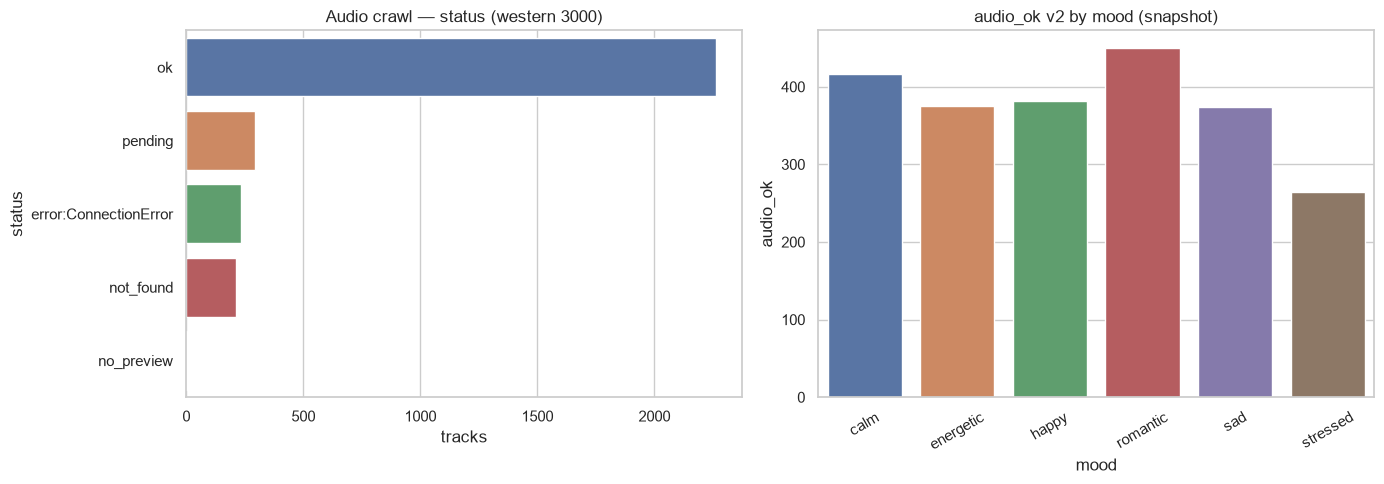

Saved C:\Users\User\Desktop\idk\ds\data\processed\figures\05_audio_crawl_snapshot.png


In [10]:
if AUDIO_SUMMARY_FILE.exists():
    audio_summary = json.loads(AUDIO_SUMMARY_FILE.read_text(encoding="utf-8"))
    mood_order = sorted(processed["mood_label"].dropna().unique())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    status_df = pd.Series(audio_summary["status_counts"]).reset_index()
    status_df.columns = ["status", "count"]
    sns.barplot(data=status_df, x="count", y="status", hue="status", ax=axes[0], legend=False)
    axes[0].set_title("Audio crawl — status (western 3000)")
    axes[0].set_xlabel("tracks")

    mood_df = pd.Series(audio_summary.get("mood_ok", {})).reindex(mood_order, fill_value=0).reset_index()
    mood_df.columns = ["mood", "audio_ok"]
    sns.barplot(data=mood_df, x="mood", y="audio_ok", hue="mood", ax=axes[1], legend=False)
    axes[1].set_title("audio_ok v2 by mood (snapshot)")
    axes[1].tick_params(axis="x", rotation=30)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "05_audio_crawl_snapshot.png", dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved {FIGURES_DIR / '05_audio_crawl_snapshot.png'}")
else:
    print("Chạy cell Bước 7b trước để tạo audio_training_summary.json")

## Bước 8 — Lưu dữ liệu đã xử lý

In [11]:
summary = {
    "initial_rows": initial_rows,
    "final_rows": len(processed),
    "duplicates_removed": initial_rows - len(processed),
    "mood_labels_inferred": inferred_count,
    "mood_distribution": processed["mood_label"].value_counts().to_dict(),
    "label_source_distribution": processed["label_source"].value_counts().to_dict(),
    "data_card": {
        "train_feature_primary": "text_content / tokens",
        "do_not_train_mood_on": "text_crawl_context, search_query, tags",
        "label_note": "mood_label từ query crawl — nhãn yếu, không vòng lặp nếu feature là metadata/audio",
    },
}
if AUDIO_SUMMARY_FILE.exists():
    audio_snap = json.loads(AUDIO_SUMMARY_FILE.read_text(encoding="utf-8"))
    summary["audio_snapshot"] = {
        "crawl_status": audio_snap.get("crawl_status"),
        "western_target": audio_snap.get("western_target"),
        "attempted": audio_snap.get("attempted"),
        "audio_ok_v2": audio_snap.get("audio_ok_v2", audio_snap.get("audio_ok")),
        "training_rows": audio_snap.get("training_rows"),
        "feature_schema": audio_snap.get("feature_schema"),
        "status_counts": audio_snap.get("status_counts"),
    }
    wt = audio_snap.get("western_target") or 0
    ok_v2 = audio_snap.get("audio_ok_v2", audio_snap.get("audio_ok")) or 0
    if wt:
        summary["audio_coverage_pct_western"] = round(ok_v2 / wt * 100, 2)

processed.to_csv(OUTPUT_FILE, index=False)
SUMMARY_FILE.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Saved {OUTPUT_FILE} ({len(processed)} tracks)")

Saved C:\Users\User\Desktop\idk\ds\data\processed\spotify_hybrid_processed.csv (10197 tracks)


## Bước 9 — Trực quan hóa

1. **Phân bố mood** (+ % class imbalance)
2. **Nguồn dữ liệu** — profile vs search
3. **Mood × nguồn** — heatmap
4. **Chất lượng nhãn mood** — search query vs suy luận vs mặc định
5. **Audio crawl snapshot** — Bước 7b → `05_audio_crawl_snapshot.png`

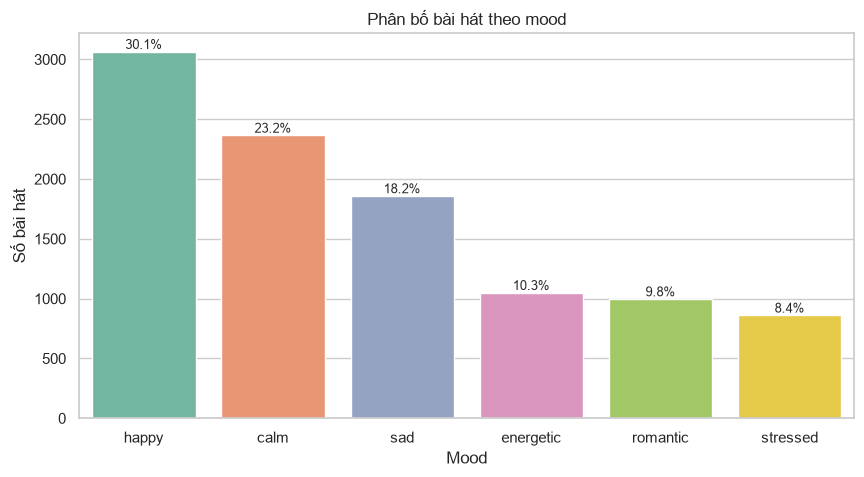

     mood  count  pct
    happy   3065 30.1
     calm   2365 23.2
      sad   1859 18.2
energetic   1050 10.3
 romantic    997  9.8
 stressed    861  8.4


In [12]:
# 1. Phân bố mood (+ %)
mood_counts = processed["mood_label"].value_counts().reset_index()
mood_counts.columns = ["mood", "count"]
mood_counts["pct"] = (mood_counts["count"] / mood_counts["count"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=mood_counts, x="mood", y="count", hue="mood", palette="Set2", ax=ax, legend=False)
for i, row in mood_counts.iterrows():
    ax.text(float(i), float(row["count"]), f"{row['pct']}%", ha="center", va="bottom", fontsize=9)
ax.set_title("Phân bố bài hát theo mood")
ax.set_xlabel("Mood")
ax.set_ylabel("Số bài hát")
fig.savefig(FIGURES_DIR / "01_mood_distribution.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

print(mood_counts.to_string(index=False))

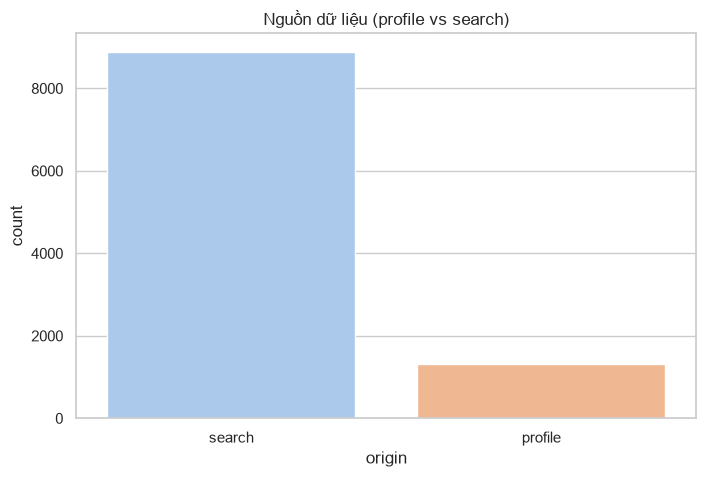

In [13]:
# 2. Nguồn dữ liệu
if "data_origin" in processed.columns:
    origin_counts = processed["data_origin"].value_counts().reset_index()
    origin_counts.columns = ["origin", "count"]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=origin_counts, x="origin", y="count", hue="origin", palette="pastel", ax=ax, legend=False)
    ax.set_title("Nguồn dữ liệu (profile vs search)")
    fig.savefig(FIGURES_DIR / "02_data_origin.png", dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

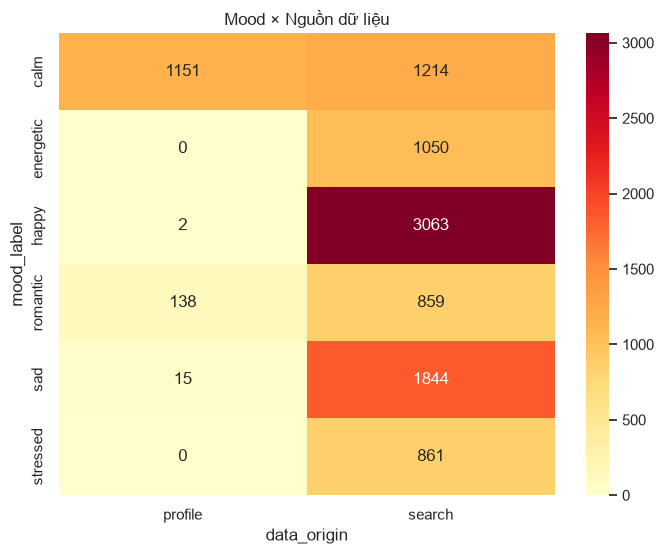

Đã lưu biểu đồ vào C:\Users\User\Desktop\idk\ds\data\processed\figures


In [14]:
# 3. Mood × nguồn dữ liệu
if "data_origin" in processed.columns:
    pivot = pd.crosstab(processed["mood_label"], processed["data_origin"])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
    ax.set_title("Mood × Nguồn dữ liệu")
    fig.savefig(FIGURES_DIR / "03_mood_origin_heatmap.png", dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

print(f"Đã lưu biểu đồ vào {FIGURES_DIR}")

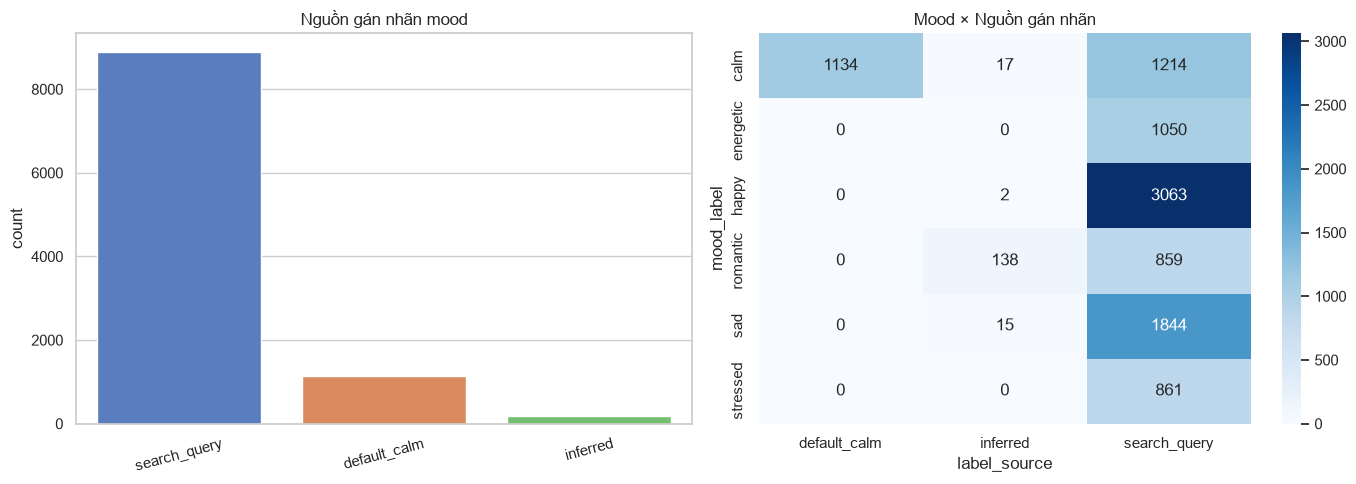

      source  count
search_query   8891
default_calm   1134
    inferred    172


In [15]:
# 4. Chất lượng nhãn mood
label_counts = processed["label_source"].value_counts().reset_index()
label_counts.columns = ["source", "count"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=label_counts, x="source", y="count", hue="source", palette="muted", ax=axes[0], legend=False)
axes[0].set_title("Nguồn gán nhãn mood")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)

label_by_mood = pd.crosstab(processed["mood_label"], processed["label_source"])
sns.heatmap(label_by_mood, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Mood × Nguồn gán nhãn")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_label_quality.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

print(label_counts.to_string(index=False))